In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_folder = Path("data")

csv_files = sorted(data_folder.glob("*.csv"))

print("Number of CSV files found:", len(csv_files))
csv_files

Number of CSV files found: 6


[WindowsPath('data/CRMLSSold202512.csv'),
 WindowsPath('data/CRMLSSold202601.csv'),
 WindowsPath('data/CRMLSSold202602.csv'),
 WindowsPath('data/CRMLSSold202603.csv'),
 WindowsPath('data/CRMLSSold202604.csv'),
 WindowsPath('data/CRMLSSold202605.csv')]

In [3]:
dfs = []

for file in csv_files:
    temp_df = pd.read_csv(file, low_memory=False)
    temp_df["SourceFile"] = file.name
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (124404, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,SourceFile
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN,CRMLSSold202512.csv
1,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1150038872,homes@roomsantacruz.com,...,5663.0,NaN,NaN,5.0,Other,95018,NaN,5663.0,NaN,CRMLSSold202512.csv
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN,CRMLSSold202512.csv
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN,CRMLSSold202512.csv
4,TriCounties,TriCounties,NaN,True,NaN,NaN,True,3300.0,1150038314,c21themvpteam@gmail.com,...,17500.0,4.0,False,2.0,Jurupa Unified,92509,0.0,17500.0,NaN,CRMLSSold202512.csv


In [7]:
# Clean column names just in case there are spaces
df.columns = df.columns.str.strip()

# Rename actual MLS column names to simpler names for EDA
df = df.rename(columns={
    "BedroomsTotal": "Bedrooms",
    "BathroomsTotalInteger": "Bathrooms",
    "LotSizeSquareFeet": "LotSize"
})

In [15]:
needed_cols = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "PropertyType",
    "PropertySubType"
]

for col in needed_cols:
    if col not in df.columns:
        print("Missing column:", col)

In [9]:
df_filtered = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print("Original rows:", df.shape[0])
print("Filtered rows:", df_filtered.shape[0])

df_filtered.head()

Original rows: 124404
Filtered rows: 61727


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSize,MiddleOrJuniorSchoolDistrict,SourceFile
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN,CRMLSSold202512.csv
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN,CRMLSSold202512.csv
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN,CRMLSSold202512.csv
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN,CRMLSSold202512.csv
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN,CRMLSSold202512.csv


In [10]:
eda_cols = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

eda_df = df_filtered[eda_cols].copy()
eda_df.head()

,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
0,1998000.0,2045.0,4.0,2.0,10080.0
2,2214421.0,3050.0,4.0,4.0,34745.0
3,1200000.0,1594.0,4.0,2.0,6600.0
7,3100000.0,2700.0,5.0,3.0,8262.0
9,2900000.0,2948.0,5.0,4.0,9222.0


In [12]:
eda_df_clean = eda_df.dropna()

print("Before dropping missing values:", eda_df.shape)
print("After dropping missing values:", eda_df_clean.shape)
eda_df_clean.describe()

Before dropping missing values: (61727, 5)
After dropping missing values: (60616, 5)


,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
count,6.061600e+04,60616.000000,60616.000000,60616.000000,6.061600e+04
mean,1.336426e+06,2056.195153,3.497938,2.642388,3.861280e+05
std,7.367486e+06,1039.028363,0.967080,1.134093,1.843857e+07
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.150000e+05,1386.000000,3.000000,2.000000,5.663000e+03
50%,8.860000e+05,1826.000000,3.000000,2.000000,7.262000e+03
75%,1.425000e+06,2457.000000,4.000000,3.000000,1.045400e+04
max,7.960000e+08,23314.000000,22.000000,22.000000,1.897474e+09


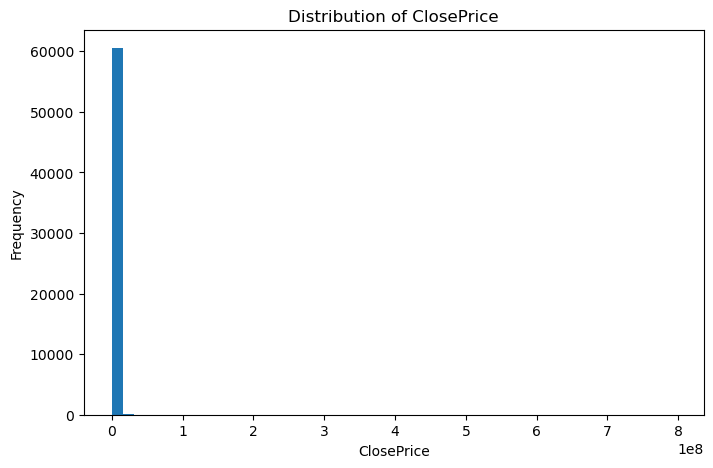

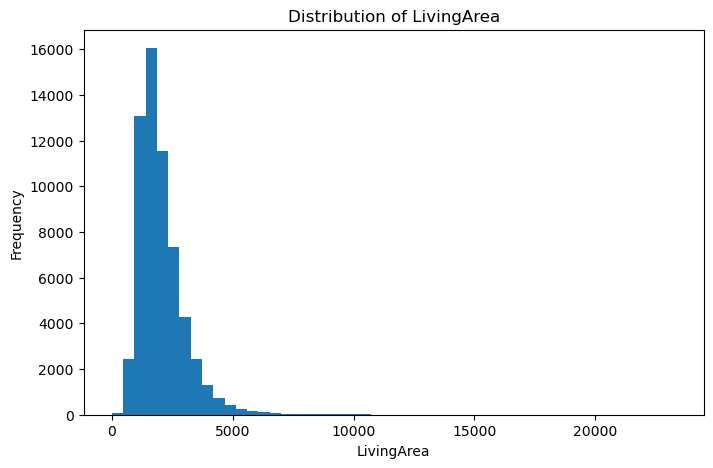

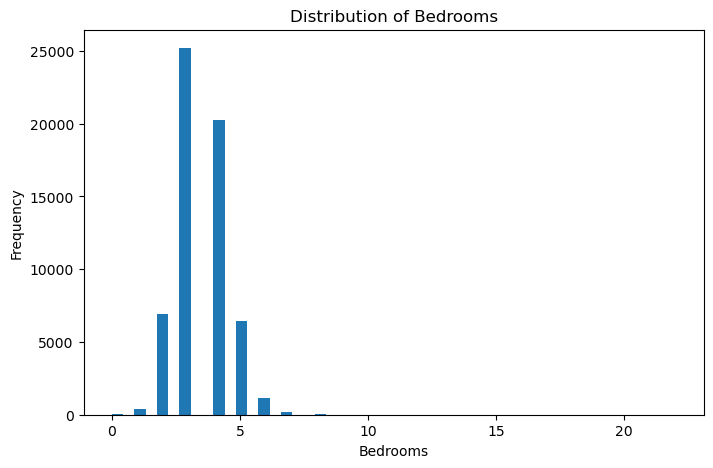

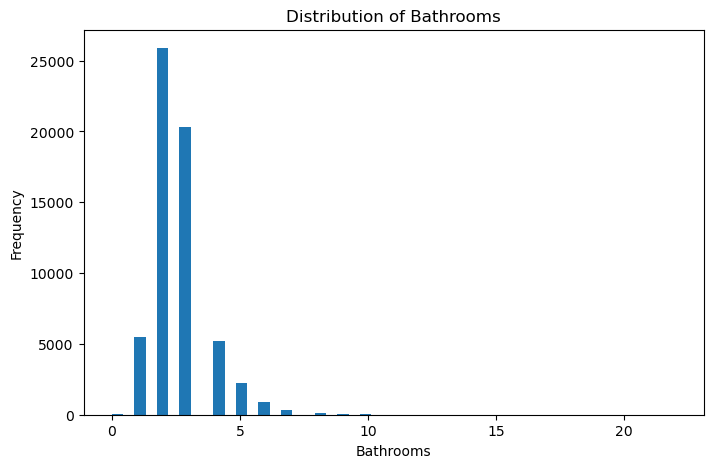

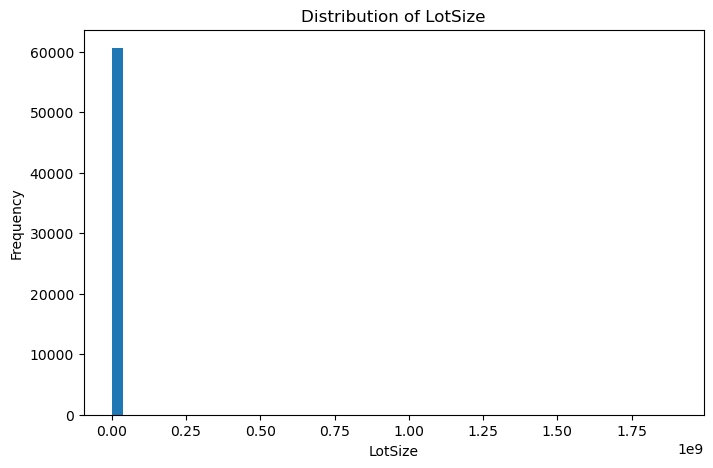

In [13]:
for col in eda_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(eda_df_clean[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

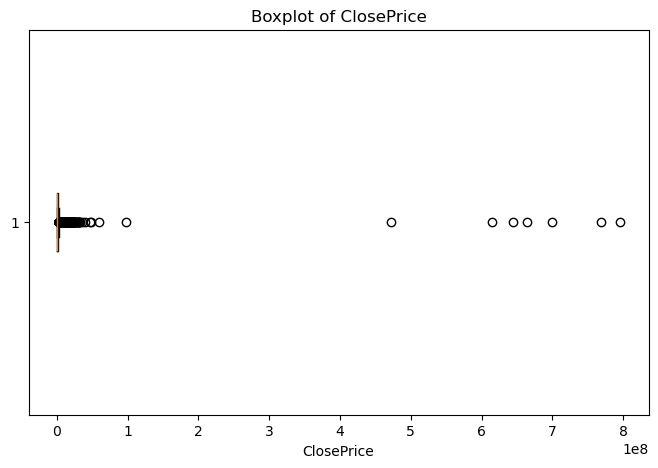

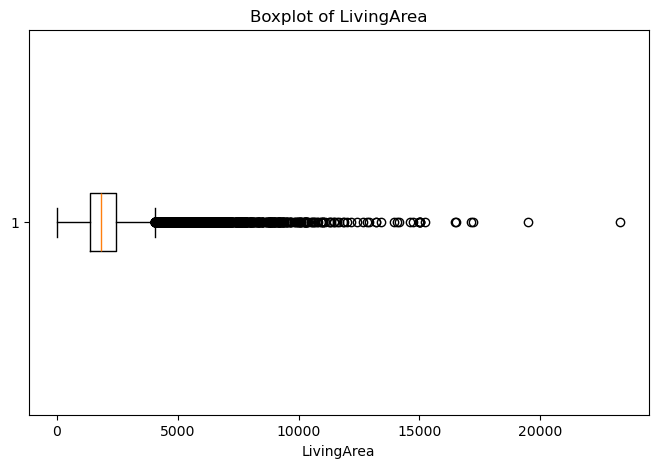

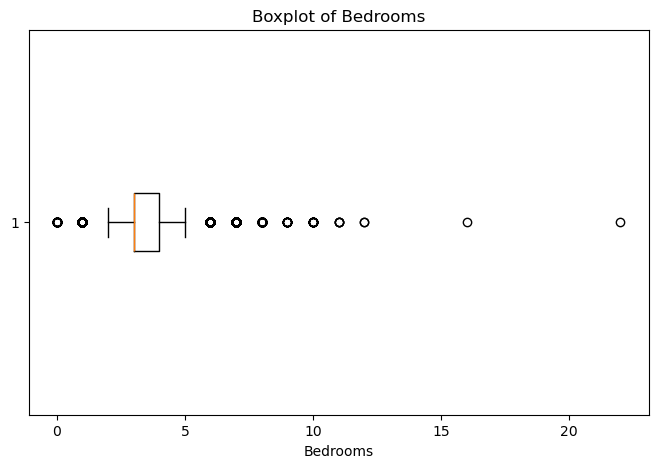

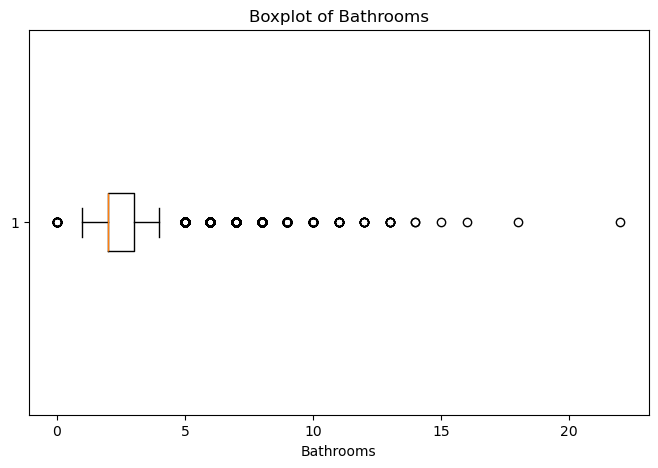

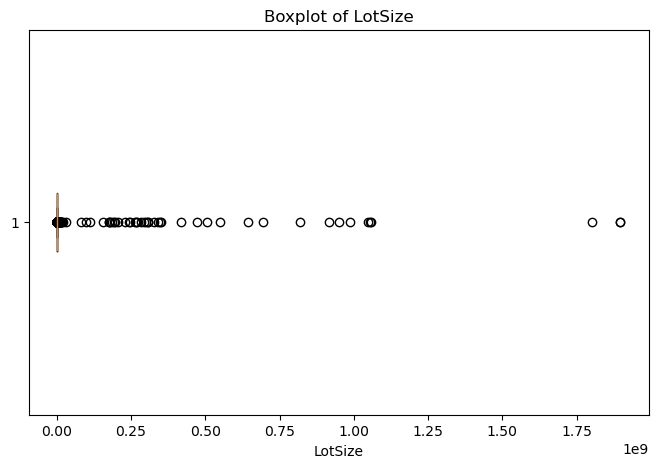

In [14]:
for col in eda_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(eda_df_clean[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()